<a href="https://colab.research.google.com/github/arthireddy14/Deep_Learning/blob/main/AI_Car_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🚗 AI System for Car Price Prediction
Business Scenario
A used car marketplace company wants to build an AI-based price recommendation system.
Currently, dealers manually estimate the price of cars based on experience. This often leads to:
Incorrect pricing
Loss of potential buyers
Inconsistent valuations
To solve this, the company wants to build an AI model that predicts the price of a car automatically based on its features.


In [3]:
import numpy as np
import pandas as pd

Build a Feed Forward Neural Network model that predicts the price of a car using the provided dataset.
The system should learn relationships between features such as:
Car brand
Fuel type
Engine size
Mileage
Transmission
Other attributes
and predict the expected car price.

CarPrice_dataset.csv
The dataset contains multiple features describing different cars.
Example features may include:
brand
fuel type
engine size
mileage
transmission
horsepower
number of doors
car body type

Target variable:
Price

🔹 Task 1 — Data Understanding
Load the dataset and analyze it.
Students must:
Load dataset using pandas
Display first 5 rows
Check dataset information
Check missing values
Show statistical summary


In [ ]:
df=pd.read_csv("CarPrice_dataset.csv")

In [5]:
df.head(10)

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.000
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.000
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.000
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.000
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.000
5,6,2,audi fox,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250.000
6,7,1,audi 100ls,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,17710.000
7,8,1,audi 5000,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,18920.000
8,9,1,audi 4000,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.40,8.3,140,5500,17,20,23875.000
9,10,0,audi 5000s (diesel),gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.40,7.0,160,5500,16,22,17859.167


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

🔹 Task 2 — Data Cleaning
Students must:
Handle missing values
Remove duplicates
Fix inconsistent data types

In [31]:
df=df.drop(columns=['car_ID'])
df['brand']=df['CarName'].apply(lambda x:x.split(' ')[0])
df=df.drop(columns=['CarName'])

In [32]:
df.isnull().sum()

,0
symboling,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0
carlength,0
carwidth,0


In [33]:
df.describe()

,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


🔹 Task 3 — Data Preprocessing
Students must prepare data for neural network.
Required steps:
Encode categorical variables
Example:
Fuel Type → Petrol / Diesel → One Hot Encoding
Transmission → Manual / Automatic
Normalize numerical features
Example:
MinMaxScaler
or
StandardScaler
Split dataset
Train → 80%
Test → 20%


In [34]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.model_selection import train_test_split

In [35]:
from pandas.core.arrays import categorical
from sklearn.compose import ColumnTransformer
x=df.drop(columns='price')
y=df['price']
categorical_col=x.select_dtypes(include=['object']).columns.tolist()
numerical_col=x.select_dtypes(include=['int64','float64']).columns.tolist()
preprocessor=ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),numerical_col),
        ('car',OneHotEncoder(handle_unknown='ignore'),categorical_col)
    ]
)
x_processed=preprocessor.fit_transform(x)
x_train,x_test,y_train,y_test=train_test_split(x_processed,y,test_size=0.2,random_state=42)

🔹 Task 4 — Build Feed Forward Neural Network
 must design an FNN model.
Architecture example:
Input Layer → Hidden Layer → Hidden Layer → Output Layer
Example configuration:
Input Layer: Number of features
Hidden Layer 1: 64 neurons (ReLU)
Hidden Layer 2: 32 neurons (ReLU)
Output Layer: 1 neuron (Price)


In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [42]:
model=Sequential([
    Dense(256,activation='relu'),
    Dense(128,activation='relu'),
    Dense(64,activation='relu'),
    Dense(32,activation='relu'),
    Dense(1,activation='linear')
])
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

🔹 Task 5 — Train the Model
You must train the neural network.
Example configuration:
Loss Function → Mean Squared Error
Optimizer → Adam
Epochs → 50
Batch Size → 32
You must visualize:
Training Loss vs Epochs

In [43]:
model.compile(optimizer='adam',loss='mean_squared_error',metrics=['mean_absolute_error'])

In [44]:
history=model.fit(x_train,y_train,epochs=70,batch_size=32,verbose=0)

In [45]:
loss, mae = model.evaluate(x_test, y_test, verbose=0)
print(f"Test MAE: {mae:.2f}")

Test MAE: 1761.96


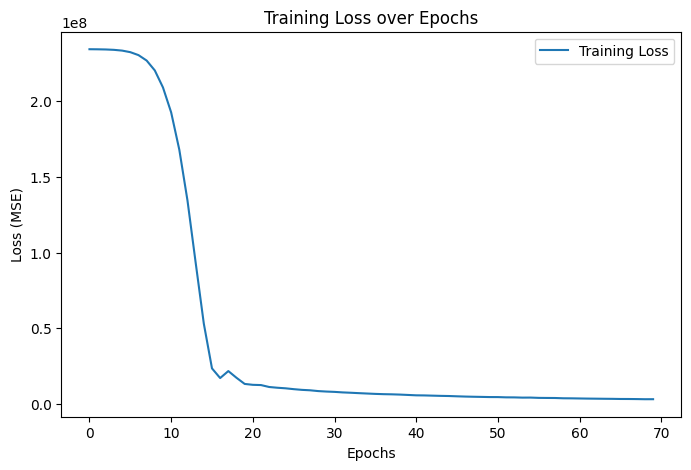

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Training Loss over Epochs')
plt.legend()
plt.show()

🔹 Task 6 — Model Evaluation
Evaluate the model using regression metrics.
Students must compute:
Mean Absolute Error (MAE)
Mean Squared Error (MSE)
Root Mean Squared Error (RMSE)
R² Score
Students must interpret:
Is the model accurate?





In [47]:
# model evaluation
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
y_pred=model.predict(x_test)
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)

print("Mean squared error ",mse)
print("Root mean squared error ",rmse)
print("Mean absolute error ",mae)
print("R2 score ",r2)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step
Mean squared error  6569526.528385667
Root mean squared error  2563.108762496369
Mean absolute error  1761.9584244474086
R2 score  0.916782468701458


🔹 Task 7 — Prediction
 must test the model with new car data.
Example:
Brand: Toyota
Fuel Type: Petrol
Engine Size: 1800
Mileage: 15 km/l
Transmission: Manual
Model should output:
Predicted Price = ₹8,45,000


In [48]:
import pandas as pd

# Example new car data
new_car = pd.DataFrame([{
    'symboling': 0,
    'brand': 'toyota',
    'fueltype': 'gas',
    'aspiration': 'std',
    'doornumber': 'four',
    'carbody': 'sedan',
    'drivewheel': 'fwd',
    'enginelocation': 'front',
    'wheelbase': 95.7,
    'carlength': 170.0,
    'carwidth': 65.5,
    'carheight': 54.3,
    'curbweight': 2300,
    'enginetype': 'ohc',
    'cylindernumber': 'four',
    'enginesize': 130,
    'fuelsystem': 'mpfi',
    'boreratio': 3.4,
    'stroke': 3.2,
    'compressionratio': 9.0,
    'horsepower': 110,
    'peakrpm': 5000,
    'citympg': 15,
    'highwaympg': 20
}])

In [49]:
# One-hot encode using same columns as training
# new_car_encoded = pd.get_dummies(new_car)
# new_car_encoded= new_car_encoded.reindex(columns=x_train.columns, fill_value=0)

# Scale numerical features
new_car_processed = preprocessor.transform(new_car)

predicted_price = model.predict(new_car_processed)

print("Predicted Price =", predicted_price[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step
Predicted Price = 13794.72


In [50]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])
pipeline.predict(new_car)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


array([[13794.72]], dtype=float32)

In [52]:
new_data=x.iloc[[0]]
new_data_processed=preprocessor.transform(new_data)
predict_price=model.predict(new_data_processed)
print(f'Predicted price : {predict_price[0][0]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
Predicted price : 15083.4501953125


In [53]:
print("Actual Price:", y.iloc[0])
print("Predicted Price:", predict_price[0][0])

Actual Price: 13495.0
Predicted Price: 15083.45
